In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("cleaned_sales_data.csv")

data.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Product,Category,Quantity,Unit_Price,Revenue,City,Payment_Method,Order_Status,Customer_Age,Sales_Channel
0,ORD0362,2025-04-25,C1081,Priya,PRINTER,Office,2.0,9999.0,19998.0,Delhi,UPI,Completed,44.0,Online
1,ORD0074,2025-02-06,C1019,Unknown,keyboard,accessories,3.0,999.0,2997.0,Ahmedabad,Net Banking,Cancelled,46.0,Online
2,ORD0375,2025-06-15,C1144,Vikram,usb cable,Unknown,4.0,499.0,1996.0,Chennai,UPI,Completed,42.0,store
3,ORD0156,2025-06-13,C1203,Rahul,USB Cable,Accessories,7.0,299.0,2093.0,Kolkata,Debit Card,Pending,65.0,Store
4,ORD0105,2025-02-01,C1243,Anjali,Tablet,Electronics,5.0,9999.0,49995.0,Hyderabad,Net Banking,Completed,21.0,online


In [2]:
#Basic statistics
data.describe()

,Quantity,Unit_Price,Revenue,Customer_Age
count,481.000000,481.000000,481.000000,481.000000
mean,5.316008,11554.070686,48807.006237,46.501040
std,11.124669,16191.582324,74492.682361,63.331967
min,1.000000,199.000000,199.000000,5.000000
25%,3.000000,999.000000,3192.000000,32.000000
50%,4.000000,3999.000000,11997.000000,42.000000
75%,6.000000,15999.000000,72000.000000,53.000000
max,200.000000,72000.000000,520000.000000,999.000000


In [3]:
#Revenue Statistics
print("Total Revenue:", data['Revenue'].sum())
print("Average Revenue:", data['Revenue'].mean())
print("Minimum Revenue:", data['Revenue'].min())
print("Maximum Revenue:", data['Revenue'].max())

Total Revenue: 23476170.0
Average Revenue: 48807.00623700624
Minimum Revenue: 199.0
Maximum Revenue: 520000.0


In [4]:
#Quantity Statistics
print("Total Quantity Sold:", data['Quantity'].sum())
print("Average Quantity:", data['Quantity'].mean())

Total Quantity Sold: 2557.0
Average Quantity: 5.316008316008316


In [5]:
#Category Analysis
category_sales = data.groupby('Category')['Revenue'].sum().sort_values(
    ascending=False
)

category_sales

Category
Electronics    13780682.0
electronics     6030872.0
Office          1242889.0
Accessories      961053.0
office           880928.0
accessories      484477.0
Unknown           95269.0
Name: Revenue, dtype: float64

In [6]:
#Product Analysis
product_sales = data.groupby('Product')['Revenue'].sum().sort_values(
    ascending=False
)

product_sales

Product
Laptop        4484000.0
Tablet        2995845.0
laptop        2183000.0
Smartphone    1700997.0
SMARTPHONE    1685000.0
LAPTOP        1418000.0
smartphone    1247000.0
Printer       1244900.0
Monitor       1135914.0
MONITOR       1121920.0
monitor        800945.0
TABLET         655953.0
PRINTER        538947.0
tablet         436974.0
printer        360967.0
Keyboard       206529.0
Webcam         204638.0
HEADPHONES     188433.0
Headphones     153921.0
webcam         137036.0
WEBCAM         119242.0
Mouse           93286.0
mouse           65117.0
MOUSE           57518.0
headphones      54473.0
KEYBOARD        49064.0
usb cable       45822.0
keyboard        45463.0
USB Cable       36887.0
USB CABLE        8379.0
Name: Revenue, dtype: float64

In [7]:
#City Analysis
city_sales = data.groupby('City')['Revenue'].sum().sort_values(
    ascending=False
)

city_sales

City
Pune         4017303.0
Hyderabad    2436497.0
Chennai      2272521.0
Delhi        2265751.0
Kolkata      2255550.0
Mumbai       2193929.0
Lucknow      2130858.0
Bangalore    1944876.0
Ahmedabad    1670700.0
Jaipur       1569344.0
Unknown       718841.0
Name: Revenue, dtype: float64

In [8]:
#Payment Method
payment_analysis = data.groupby(
    'Payment_Method'
)['Revenue'].agg(['sum', 'mean', 'count'])

payment_analysis

,sum,mean,count
Payment_Method,,,
Cash,4791754.0,48895.448980,98
Credit Card,5103650.0,53163.020833,96
Debit Card,4250800.0,48859.770115,87
Net Banking,4563545.0,48548.351064,94
UPI,4396659.0,45798.531250,96
Unknown,369762.0,36976.200000,10


In [9]:
#Sales Channel
channel_analysis = data.groupby(
    'Sales_Channel'
)['Revenue'].agg(['sum', 'mean', 'count'])

channel_analysis

,sum,mean,count
Sales_Channel,,,
ONLINE,5254032.0,53071.030303,99
Online,5349446.0,51936.368932,103
Store,4185006.0,52312.575000,80
online,5018741.0,53390.861702,94
store,3668945.0,34942.333333,105


In [10]:
#Order Status
status_analysis = data.groupby(
    'Order_Status'
)['Revenue'].agg(['sum', 'mean', 'count'])

status_analysis

,sum,mean,count
Order_Status,,,
Cancelled,5900381.0,43706.525926,135
Completed,11006727.0,50030.577273,220
Pending,6569062.0,52135.412698,126


In [13]:
#Age Analysis
print("Average Customer Age:",
      data['Customer_Age'].mean())

print("Youngest Customer:",
      data['Customer_Age'].min())

print("Oldest Customer:",
      data['Customer_Age'].max())



Average Customer Age: 46.5010395010395
Youngest Customer: 5.0
Oldest Customer: 999.0


In [14]:
#Correlation
numeric_columns = [
    'Quantity',
    'Unit_Price',
    'Revenue',
    'Customer_Age'
]

correlation = data[numeric_columns].corr()

correlation

,Quantity,Unit_Price,Revenue,Customer_Age
Quantity,1.000000,-0.042318,0.037769,0.012942
Unit_Price,-0.042318,1.000000,0.816914,-0.016979
Revenue,0.037769,0.816914,1.000000,0.010642
Customer_Age,0.012942,-0.016979,0.010642,1.000000


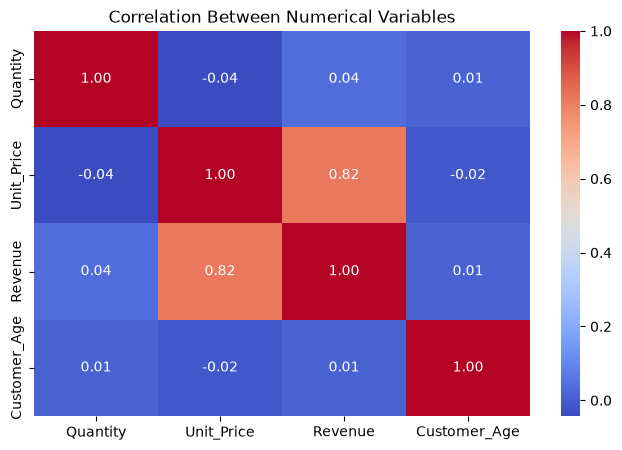

In [15]:
#Correlation Heatmap
plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between Numerical Variables')
plt.show()

In [17]:
#Detect Revenue Outliers
Q1 = data['Revenue'].quantile(0.25)
Q3 = data['Revenue'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[
    (data['Revenue'] < lower_bound) |
    (data['Revenue'] > upper_bound)
]

print("Number of revenue outliers:", len(outliers))

Number of revenue outliers: 28


In [18]:
#view Outliers
outliers[
    ['Order_ID', 'Product', 'Quantity', 'Unit_Price', 'Revenue']
].sort_values('Revenue', ascending=False)

,Order_ID,Product,Quantity,Unit_Price,Revenue
158,ORD0061,Laptop,8.0,65000.0,520000.0
425,ORD0242,Laptop,7.0,65000.0,455000.0
198,ORD0468,Laptop,4.0,72000.0,432000.0
134,ORD0058,Laptop,6.0,72000.0,432000.0
364,ORD0231,Laptop,5.0,72000.0,360000.0
84,ORD0091,laptop,4.0,65000.0,325000.0
272,ORD0299,Laptop,6.0,52000.0,312000.0
376,ORD0464,LAPTOP,6.0,52000.0,312000.0
16,ORD0433,Laptop,4.0,72000.0,288000.0
138,ORD0266,laptop,4.0,72000.0,288000.0


In [20]:
#Monthly Trend
data['Order_Date'] = pd.to_datetime(data['Order_Date'])

data['Month'] = data['Order_Date'].dt.to_period('M')

monthly_sales = data.groupby('Month')['Revenue'].sum()

monthly_sales

Month
2025-01    4331700.0
2025-02    3381957.0
2025-03    3028941.0
2025-04    6503317.0
2025-05    2952141.0
2025-06    3085121.0
2025-07     126000.0
2025-09      63996.0
2025-12       2997.0
Freq: M, Name: Revenue, dtype: float64

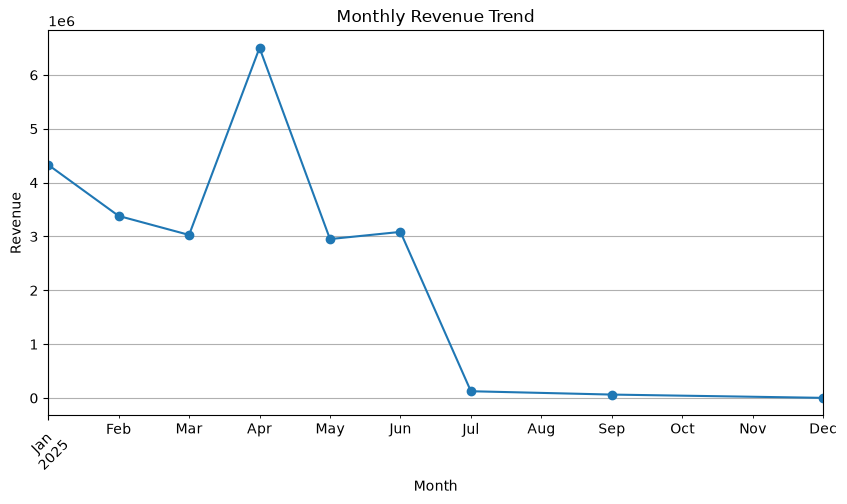

In [21]:
#Monthly Revenue Graph
plt.figure(figsize=(10, 5))

monthly_sales.plot(marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

BUSINESS QUESTIONS FOR TASK_2

In [22]:
#Which product generates the highest revenue?

top_product = data.groupby(
    'Product'
)['Revenue'].sum().sort_values(ascending=False)

print("Top Product:")
print(top_product.head(1))

Top Product:
Product
Laptop    4484000.0
Name: Revenue, dtype: float64


In [23]:
#Which city generates the highest revenue?

top_city = data.groupby(
    'City'
)['Revenue'].sum().sort_values(ascending=False)

print(top_city.head(1))

City
Pune    4017303.0
Name: Revenue, dtype: float64


In [24]:
#Which sales channel generates more revenue?

channel_revenue = data.groupby(
    'Sales_Channel'
)['Revenue'].sum().sort_values(ascending=False)

channel_revenue

Sales_Channel
Online    5349446.0
ONLINE    5254032.0
online    5018741.0
Store     4185006.0
store     3668945.0
Name: Revenue, dtype: float64

In [25]:
#Which payment method is most popular?

data['Payment_Method'].value_counts()

Payment_Method
Cash           98
UPI            96
Credit Card    96
Net Banking    94
Debit Card     87
Unknown        10
Name: count, dtype: int64

In [26]:
#Which Category generates the most revenue?

data.groupby(
    'Category'
)['Revenue'].sum().sort_values(ascending=False)

Category
Electronics    13780682.0
electronics     6030872.0
Office          1242889.0
Accessories      961053.0
office           880928.0
accessories      484477.0
Unknown           95269.0
Name: Revenue, dtype: float64